# Solutions — 00 Intro to AnnData

Worked solutions to the homework in `notebooks/00_intro_anndata.ipynb`.
Try the exercises yourself first — this is here for you to self-check
afterward, not to read before attempting.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt

sc.settings.verbosity = 1
plt.rcParams["figure.dpi"] = 100

DATA_DIR = "/Users/ugobruzadinnunes/Documents/GitHub/sea-ad-multiome-cortex/data"
RNA_DIR = f"{DATA_DIR}/rna"

DONOR_IDS = [
    "H20.33.001", "H20.33.002", "H20.33.004", "H20.33.005",
    "H20.33.012", "H20.33.013", "H20.33.017", "H21.33.003",
]

donor = "H20.33.001"
adata = sc.read_h5ad(f"{RNA_DIR}/{donor}_RNAseq_final-nuclei.h5ad")
raw = adata.layers["UMIs"]

## Q1 — Load a different donor and compare shape

In [2]:
donor2 = "H20.33.017"
adata2 = sc.read_h5ad(f"{RNA_DIR}/{donor2}_RNAseq_final-nuclei.h5ad")

print(f"{donor}:  shape = {adata.shape}")
print(f"{donor2}:  shape = {adata2.shape}")
print(f"\nDifference in nuclei count: {adata2.n_obs - adata.n_obs:+,}")
print(f"Ratio: {adata2.n_obs / adata.n_obs:.2f}x")
# H20.33.017 has noticeably fewer nuclei than H20.33.001 -- consistent with it
# also being the smallest RNA h5ad file on disk (382MB vs 570MB).

H20.33.001:  shape = (19297, 36601)
H20.33.017:  shape = (14694, 36601)

Difference in nuclei count: -4,603
Ratio: 0.76x


## Q2 — Log-scale x-axis histogram

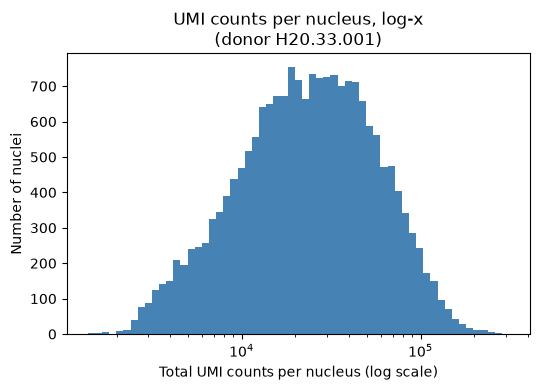

In [3]:
counts_per_nucleus = np.asarray(raw.sum(axis=1)).flatten()

fig, ax = plt.subplots(figsize=(5.5, 4))
bins = np.logspace(np.log10(counts_per_nucleus[counts_per_nucleus > 0].min()),
                    np.log10(counts_per_nucleus.max()), 60)
ax.hist(counts_per_nucleus, bins=bins, color="steelblue")
ax.set_xscale("log")
ax.set_xlabel("Total UMI counts per nucleus (log scale)")
ax.set_ylabel("Number of nuclei")
ax.set_title(f"UMI counts per nucleus, log-x\n(donor {donor})")
plt.tight_layout()
plt.show()

On a log-x axis the distribution looks much closer to symmetric/unimodal
(roughly log-normal) rather than the sharply right-skewed shape on a linear
axis. This is typical of count data: multiplicative/proportional variation
(a nucleus having "2x the RNA" of another) looks additive on a log scale,
which is exactly the intuition behind log-transforming expression data
before PCA in notebook 02.

## Q3 — Interpretation: most abundant Class

In [4]:
print(adata.obs["Class"].value_counts())

Class
Neuronal: Glutamatergic        12044
Neuronal: GABAergic             4013
Non-neuronal and Non-neural     3240
Name: count, dtype: int64


**Answer:** `Neuronal: Glutamatergic` (excitatory neurons) is the most
abundant class, followed by `Non-neuronal and Non-neural`, then
`Neuronal: GABAergic` (inhibitory neurons). This matches expectation:
cortical tissue is roughly 70-80% excitatory and 20-30% inhibitory among
neurons, and excitatory neurons are also simply the most numerous cell
type overall in cortex — consistent with the classic ~4:1
excitatory:inhibitory ratio reported in human/primate cortex literature.

## Q4 — Fraction of nuclei with a paired ATAC profile

In [5]:
method_counts = adata.obs["method"].value_counts()
frac_multiome = method_counts["10xMulti"] / method_counts.sum()
print(method_counts)
print(f"\nFraction of {donor}'s nuclei with paired ATAC (method=='10xMulti'): {frac_multiome:.1%}")

method
10Xv3.1     14644
10xMulti     4653
Name: count, dtype: int64

Fraction of H20.33.001's nuclei with paired ATAC (method=='10xMulti'): 24.1%
